In [32]:
# Duffing Oscillator Exploration
# =================================
# This notebook explores the dynamics of the Duffing oscillator —
# a classic nonlinear system that exhibits both periodic and chaotic behaviour
# depending on parameter values.

# Author: Riddhika Mahalanabis
# Date: 31.10.2025 Edited: 30.4.2026

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use('seaborn-v0_8-darkgrid')

#1. Duffing Oscillator : Governing Equations

$\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t)$

## 2. Conversion to First-Order System

Since this is a second-order differential equation, it has to be separated into two first order differential equations for any ODE solver to handle it.

The modified equation becomes :

$\dot{x} = v$

$\dot{v} = - \delta v - \alpha x - \beta x^3 + \gamma \cos(\omega t)$

In [27]:
def duffing(t, y, delta=0.2, alpha=-1.0, beta=1.0, gamma=0.3, omega=1.2):
    """
    Duffing oscillator:
    x'' + delta*x' + alpha*x + beta*x^3 = gamma*cos(omega*t)
    """
    x, v = y
    dxdt = v
    dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
    return [dxdt, dvdt]

def solve_duffing(t_span=(0, 5000), y0=(0, 0), dt=0.1, **params):
    """Numerically solve the Duffing oscillator."""
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(lambda t, y: duffing(t, y, **params), t_span, y0, t_eval=t_eval)
    return sol.t, sol.y


## 3. Parameters

In [28]:
params = dict(delta=0.25, alpha=-1.0, beta=1.0, gamma=0.3, omega=1.0)
t, y = solve_duffing(y0=(0.1, 0.0), **params)   #y0 is the initial condition

x, v = y
print(f"Integration complete: {len(t)} time points")

Integration complete: 50000 time points


# 4. Results
## 4.1 Time Series



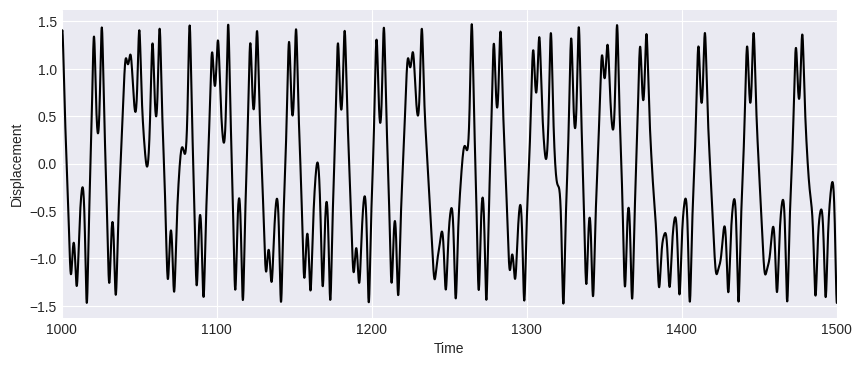

In [29]:
## Time-series plot

plt.figure(figsize=(10,4))
plt.plot(t, x, 'k', label="x(t)")
plt.xlim(1000, 1500)
plt.xlabel("Time")
plt.ylabel("Displacement")
#plt.legend()
plt.show()

## 4.2 Phase Portrait

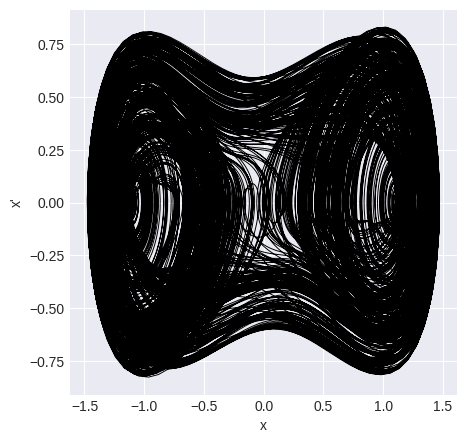

In [30]:
## Phase portrait

plt.figure(figsize=(5,5))
plt.plot(x[4000:], v[4000:], 'k', lw=0.7)
plt.xlabel("x")
plt.ylabel("x'")
plt.show()


## 4.3 Poincaré Section

The Poincaré section samples the system once every driving period, reducing the continuous trajectory to a discrete map and revealing the underlying structure of the dynamics.

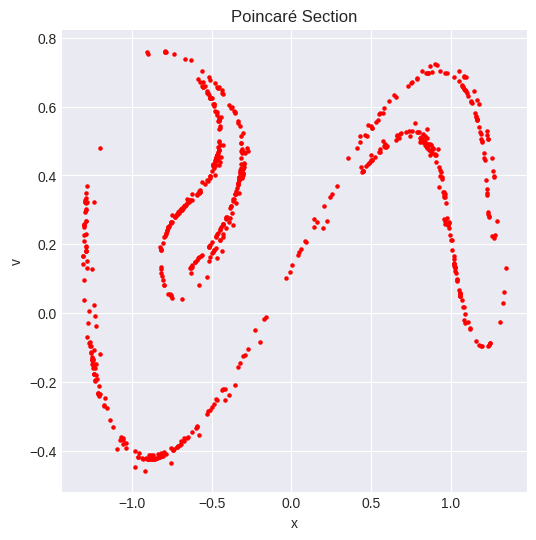

In [31]:
# Driving frequency
omega = 1.0  # use the omega values used before in the main equation

# Period of forcing
T = 2 * np.pi / omega
n_points = int(t[-1] / T)

t_poincare = np.array([n*T for n in range(n_points)])

# interpolate
x_poincare = np.interp(t_poincare, t, x)
v_poincare = np.interp(t_poincare, t, v)

# remove transient
cut = int(0.1 * len(x_poincare))
x_poincare = x_poincare[cut:]
v_poincare = v_poincare[cut:]


# Plot
plt.figure(figsize=(6,6))
plt.scatter(x_poincare, v_poincare, color = 'red', s=5)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Poincaré Section")
#plt.grid()
plt.show()